In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("../data/processed/experiment_data_clean.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (50000, 20)
   user_id  session_id variant device_type traffic_source country  \
0    25795           1       a      mobile        organic  canada   
1    10860           2       a      mobile        organic  canada   
2    86820           3       a      mobile        organic   india   
3    64886           4       b      tablet        organic      us   
4    16265           5       a     desktop        organic      us   

   is_new_user age_group  pages_viewed  clicked_recommendation  watch_started  \
0            1     18-24             3                       0              1   
1            1     45-54             8                       0              0   
2            1     25-34             4                       0              0   
3            0       55+             6                       1              0   
4            0     35-44             4                       0              0   

   minutes_watched  signed_up  retained_7d  session_duration_sec  \
0          

## ML objective

The goal of this model is to predict whether a session results in signup conversion (`signed_up`) based on user attributes, behavior, and experiment assignment.

Target:
- `signed_up`

This helps estimate which features are most associated with conversion and whether experiment treatment contributes meaningfully to signup probability.

In [2]:
feature_cols = [
    "variant",
    "device_type",
    "traffic_source",
    "country",
    "is_new_user",
    "age_group",
    "pages_viewed",
    "clicked_recommendation",
    "watch_started",
    "minutes_watched",
    "session_duration_sec"
]

target_col = "signed_up"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 11)
y shape: (50000,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target mean:", y_train.mean())
print("Test target mean:", y_test.mean())

Train shape: (40000, 11)
Test shape: (10000, 11)
Train target mean: 0.064275
Test target mean: 0.0643


In [4]:
numeric_features = [
    "is_new_user",
    "pages_viewed",
    "clicked_recommendation",
    "watch_started",
    "minutes_watched",
    "session_duration_sec"
]

categorical_features = [
    "variant",
    "device_type",
    "traffic_source",
    "country",
    "age_group"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['is_new_user', 'pages_viewed', 'clicked_recommendation', 'watch_started', 'minutes_watched', 'session_duration_sec']
Categorical features: ['variant', 'device_type', 'traffic_source', 'country', 'age_group']


In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [6]:
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.9357
Precision: 0.0
Recall: 0.0
F1 score: 0.0
ROC-AUC: 0.5831


In [8]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      9357
           1       0.00      0.00      0.00       643

    accuracy                           0.94     10000
   macro avg       0.47      0.50      0.48     10000
weighted avg       0.88      0.94      0.90     10000



In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9357    0]
 [ 643    0]]


In [10]:
classifier = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print(coef_df.head(15))

                            feature  coefficient  abs_coefficient
6                    cat__variant_a    -0.602519         0.602519
7                    cat__variant_b    -0.509947         0.509947
8          cat__device_type_desktop    -0.416243         0.416243
10          cat__device_type_tablet    -0.376777         0.376777
9           cat__device_type_mobile    -0.319445         0.319445
15  cat__traffic_source_paid_social    -0.294355         0.294355
13      cat__traffic_source_organic    -0.292732         0.292732
21             cat__age_group_18-24    -0.256171         0.256171
11       cat__traffic_source_direct    -0.254017         0.254017
19                  cat__country_uk    -0.248683         0.248683
20                  cat__country_us    -0.245649         0.245649
24             cat__age_group_45-54    -0.240535         0.240535
18               cat__country_india    -0.234453         0.234453
14  cat__traffic_source_paid_search    -0.216427         0.216427
23        

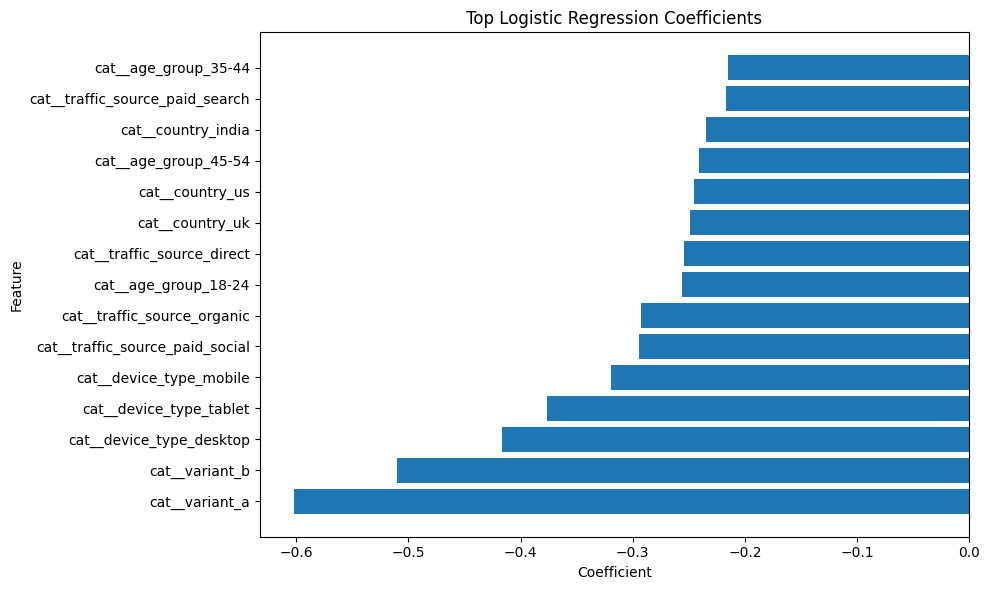

In [11]:
top_features = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/charts/logistic_regression_top_features.png")
plt.show()

In [12]:
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    "value": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df.to_csv("../outputs/reports/ml_model_metrics.csv", index=False)
coef_df.to_csv("../outputs/reports/ml_model_coefficients.csv", index=False)

print("Saved:")
print("../outputs/reports/ml_model_metrics.csv")
print("../outputs/reports/ml_model_coefficients.csv")

Saved:
../outputs/reports/ml_model_metrics.csv
../outputs/reports/ml_model_coefficients.csv


## ML interpretation

A logistic regression model was trained to predict signup conversion using experiment assignment, user attributes, and behavioral features.

Key value:
- Identifies which factors are most associated with conversion
- Helps explain which behaviors signal high purchase intent
- Shows whether treatment assignment contributes to conversion probability

This complements A/B testing by adding predictive insight beyond simple aggregate comparisons.

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [14]:
cluster_features = [
    "pages_viewed",
    "clicked_recommendation",
    "watch_started",
    "minutes_watched",
    "session_duration_sec"
]

cluster_df = df[cluster_features].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print(cluster_df.head())

   pages_viewed  clicked_recommendation  watch_started  minutes_watched  \
0             3                       0              1            32.03   
1             8                       0              0             0.89   
2             4                       0              0             1.13   
3             6                       1              0             2.50   
4             4                       0              0             0.63   

   session_duration_sec  
0                   517  
1                   456  
2                    80  
3                   283  
4                   200  


In [15]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

print(df["cluster"].value_counts())

cluster
2    33207
0     9532
1     7261
Name: count, dtype: int64


In [ ]:
cluster_summary = df.groupby(
    "cluster")[cluster_features + ["signed_up"]].mean().round(2)
print(cluster_summary)

         pages_viewed  clicked_recommendation  watch_started  minutes_watched  \
cluster                                                                         
0                4.99                    1.00            0.0             2.03   
1                5.04                    0.34            1.0            30.00   
2                5.00                    0.00            0.0             2.00   

         session_duration_sec  signed_up  
cluster                                   
0                      228.08       0.08  
1                      539.38       0.10  
2                      197.77       0.05  


In [17]:
cluster_summary.to_csv("../outputs/reports/cluster_summary.csv")
print("Saved ../outputs/reports/cluster_summary.csv")

Saved ../outputs/reports/cluster_summary.csv


## Cluster interpretation

User sessions were grouped into behavioral clusters using KMeans.

Example segment types:
- low-engagement browsers
- medium-intent evaluators
- high-intent engaged users

This supports audience understanding and can help target future experiments to the segments most likely to convert.

## AI-generated business summary layer

A reporting layer was added to transform experiment metrics, model outputs, and segment-level uplift into a business-style executive summary.

This helps simulate how AI can reduce manual reporting effort and support faster decision-making for product and growth teams.